## CS421 Anomaly Detection 

#### Name: Justin Goh Kai Jun, Leong Zhe Cheng, Durga D/O Chandrasekaran
#### Group: G1T8

**Step 1: Imports & Setup**

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy, rankdata, spearmanr, pearsonr
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds

from sklearn.svm import OneClassSVM
from sklearn.ensemble import (IsolationForest, RandomForestClassifier,
                               ExtraTreesClassifier, GradientBoostingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                              recall_score, roc_curve, precision_recall_curve)
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import warnings, os
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

# Minimum AUC a model needs to enter the ensemble
ENSEMBLE_AUC_THRESHOLD = 0.60
# Minimum CV-F1 a supervised model needs to avoid penalty
MIN_CV_F1 = 0.30

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cpu


**Step 2: Load Data**

In [2]:
data  = np.load('../training_batch_with_labels.npz')
X_raw = data['X']
y_raw = data['y']

XX        = pd.DataFrame(X_raw, columns=['user', 'item', 'rating'])
yy        = pd.DataFrame(y_raw, columns=['user', 'label'])
label_map = dict(zip(yy['user'], yy['label']))

print(f'Total interactions : {XX.shape[0]:,}')
print(f'Anomalous users    : {(yy["label"]==1).sum()}')
print(f'Normal users       : {(yy["label"]==0).sum()}')
print(f'Unique users       : {XX["user"].nunique()}')
print(f'Anomaly ratio      : {(yy["label"]==1).mean():.2%}')
print(f'Unique items       : {XX["item"].nunique()}')

Total interactions : 177,346
Anomalous users    : 100
Normal users       : 1000
Unique users       : 1100
Anomaly ratio      : 9.09%
Unique items       : 993


In [3]:
# ITERATIVE: load newly released test labels
LABEL_DIR = '../released_labels'

extra_files = []
if os.path.exists(LABEL_DIR):
    extra_files = sorted([f for f in os.listdir(LABEL_DIR) if f.startswith('released_week')])

extra_interactions, extra_labels = [], []
for fname in extra_files:
    d   = np.load(os.path.join(LABEL_DIR, fname))
    df  = pd.DataFrame(d['X'], columns=['user', 'item', 'rating'])
    offset = (extra_files.index(fname) + 1) * 10_000
    df['user'] = df['user'] + offset
    lbl = pd.DataFrame(d['y'], columns=['user', 'label'])
    lbl['user'] = lbl['user'] + offset
    extra_interactions.append(df)
    extra_labels.append(lbl)
    print(f'  Loaded {fname}: {len(df):,} interactions, {(lbl["label"]==1).sum()} anomalies')

if extra_interactions:
    XX = pd.concat([XX] + extra_interactions, ignore_index=True)
    yy = pd.concat([yy] + extra_labels,       ignore_index=True)
    for lbl_df in extra_labels:
        label_map.update(dict(zip(lbl_df['user'], lbl_df['label'])))
    print(f'\nAfter stacking: {XX.shape[0]:,} interactions, {(yy["label"]==1).sum()} anomalies')
else:
    print('No extra label files found. Running on original training data only.')

  Loaded released_week9.npz: 167,493 interactions, 100 anomalies

After stacking: 344,839 interactions, 200 anomalies


**Step 3: Enhanced Feature Engineering**

In [4]:
def compute_item_stats(interactions_df):
    """Compute item-level stats (mean rating, count, popularity rank)."""
    item_mean     = interactions_df.groupby('item')['rating'].mean()
    item_count    = interactions_df.groupby('item')['rating'].count()
    item_pop_rank = item_count.rank(pct=True)
    return item_mean, item_count, item_pop_rank


def compute_svd_features(interactions_df, n_components=8):
    """
    Truncated SVD on the user × item rating matrix.
    Returns:
        user_latent  : (n_users, n_components) — latent user factors
        recon_errors : (n_users,) — per-user reconstruction error
        user_ids     : ordered list matching rows
    """
    user_ids  = interactions_df['user'].unique()
    item_ids  = interactions_df['item'].unique()
    u2i = {u: i for i, u in enumerate(user_ids)}
    i2i = {it: i for i, it in enumerate(item_ids)}

    rows = interactions_df['user'].map(u2i).values
    cols = interactions_df['item'].map(i2i).values
    vals = interactions_df['rating'].values.astype(np.float32)

    R = csr_matrix((vals, (rows, cols)), shape=(len(user_ids), len(item_ids)))

    k = min(n_components, min(R.shape) - 1)
    U, S, Vt = svds(R, k=k)

    # User latent factors (scaled by singular values)
    user_latent = U * S[np.newaxis, :]            # (n_users, k)

    # Reconstruction error (only on rated entries)
    R_approx = (U * S[np.newaxis, :]) @ Vt        # dense approximation
    R_dense  = R.toarray()
    mask     = (R_dense != 0).astype(np.float32)
    residual = (R_dense - R_approx) * mask
    n_rated  = mask.sum(axis=1)
    recon_errors = np.where(n_rated > 0,
                            np.sum(residual**2, axis=1) / (n_rated + 1e-9),
                            0.0)

    return user_latent, recon_errors, user_ids

In [5]:
SVD_K = 8   # SVD latent dimensions

ALL_FEATURE_NAMES = [
    # ── Rating statistics ────────────────────────────────────────────────────
    'mean_r', 'std_r', 'variance_r', 'min_r', 'max_r', 'range_r',
    'star0', 'star1', 'star2', 'star3', 'star4', 'star5',
    'entropy',
    'frac_extreme', 'frac_zero', 'frac_five', 'frac_mid',
    'frac_45', 'frac_01', 'bimodal', 'rating_skew',
    # ── robust rating stats ──────────────────────────────────────────
    'mad_r',           # median absolute deviation
    'trimmed_mean_r',  # 10% trimmed mean
    # ── Interaction / item features ──────────────────────────────────────────
    'n_inter', 'n_unique_items', 'density',
    'mean_gap', 'std_gap', 'min_gap',
    'sequential_run_frac', 'item_autocorr', 'burst_score', 'n_repeat_items',
    # ── Cosine deviation from normal centroid ────────────────────────────────
    'cosine_dev',
    # ── Attack-profile features ──────────────────────────────────────────────
    'avg_attack_score', 'bandwagon_score', 'random_attack_score',
    'popular_item_frac', 'unpopular_item_frac', 'segment_score',
    'love_hate_score', 'rating_deviation_std',
    # NEW: filler-item ratio (bandwagon/average attack signal)
    'filler_item_frac',
    # ── Attack-type-agnostic features ────────────────────────────────────────
    'gini_items', 'rating_zscore_mean', 'rating_zscore_std',
    'entropy_zscore', 'n_inter_zscore', 'item_coverage',
    # NEW: correlation with item mean ratings
    'rating_vs_item_corr',
    # ── SVD / spectral features (filled in post-loop) ────────────────────────
    'svd_recon_error',
    'svd_latent_dist',
] + [f'svd_{i}' for i in range(SVD_K)]

print(f'Total features: {len(ALL_FEATURE_NAMES)}')

Total features: 60


In [6]:
# ── Globals for z-score features ─────────────────────────────────────────────
NORMAL_MEAN_R    = None
NORMAL_STD_R     = None
NORMAL_STD_STD   = None
NORMAL_ENT_MEAN  = None
NORMAL_ENT_STD   = None
NORMAL_NINT_MEAN = None
NORMAL_NINT_STD  = None


def engineer_all_features(interactions_df, n_items=1000, normal_centroid=None,
                           item_mean=None, item_count=None, item_pop_rank=None,
                           svd_latent=None, svd_recon=None, svd_user_ids=None,
                           svd_normal_centroid=None):
    """
    Build per-user feature matrix.
    Returns (feat_arr, user_ids, normal_centroid).
    """
    global NORMAL_MEAN_R, NORMAL_STD_R, NORMAL_STD_STD
    global NORMAL_ENT_MEAN, NORMAL_ENT_STD, NORMAL_NINT_MEAN, NORMAL_NINT_STD

    if item_mean is None:
        item_mean, item_count, item_pop_rank = compute_item_stats(interactions_df)

    # Filler items: top 20% most-rated items (attack users disproportionately rate these)
    filler_items = set(item_pop_rank[item_pop_rank >= 0.80].index)
    popular_items   = set(item_pop_rank[item_pop_rank >= 0.80].index)
    unpopular_items = set(item_pop_rank[item_pop_rank <= 0.20].index)

    # Map svd arrays to dict for O(1) lookup
    svd_map   = {}  # uid -> (latent_vec, recon_err)
    if svd_latent is not None and svd_user_ids is not None:
        for idx, uid in enumerate(svd_user_ids):
            svd_map[uid] = (svd_latent[idx], svd_recon[idx])

    features = []
    user_ids = interactions_df['user'].unique()

    for uid in user_ids:
        u_df    = interactions_df[interactions_df['user'] == uid]
        ratings = u_df['rating'].values.astype(float)
        items   = u_df['item'].values

        # ── Basic rating stats ────────────────────────────────────────────────
        mean_r     = ratings.mean()
        std_r      = ratings.std()   if len(ratings) > 1 else 0.0
        variance_r = ratings.var()   if len(ratings) > 1 else 0.0
        min_r, max_r = ratings.min(), ratings.max()
        range_r    = max_r - min_r

        star_fracs     = np.bincount(ratings.astype(int), minlength=6) / max(len(ratings), 1)
        rating_entropy = entropy(star_fracs + 1e-9)

        frac_extreme = np.mean((ratings == 0) | (ratings == 5))
        frac_zero    = np.mean(ratings == 0)
        frac_five    = np.mean(ratings == 5)
        frac_mid     = np.mean((ratings >= 2) & (ratings <= 3))
        frac_45      = np.mean(ratings >= 4)
        frac_01      = np.mean(ratings <= 1)
        bimodal      = frac_45 + frac_01
        rating_skew  = ((ratings - mean_r)**3).mean() / (std_r**3 + 1e-9)

        # Median Absolute Deviation (robust spread)
        mad_r = np.median(np.abs(ratings - np.median(ratings)))

        # 10% trimmed mean (resistant to artificial extreme ratings)
        n_trim = max(1, int(0.1 * len(ratings)))
        sorted_r = np.sort(ratings)
        trimmed_mean_r = sorted_r[n_trim:-n_trim].mean() if len(sorted_r) > 2*n_trim else mean_r

        # ── Interaction / item features ───────────────────────────────────────
        n_interactions = len(ratings)
        n_unique_items = len(np.unique(items))
        density        = n_interactions / n_items
        item_counts_u  = pd.Series(items).value_counts()
        n_repeat_items = (item_counts_u > 1).sum() / max(len(item_counts_u), 1)

        sorted_items = np.sort(items)
        item_gaps    = np.diff(sorted_items) if len(sorted_items) > 1 else np.array([0])
        mean_gap     = item_gaps.mean()
        std_gap      = item_gaps.std()  if len(item_gaps) > 1 else 0.0
        min_gap      = item_gaps.min()
        sequential_run_frac = (item_gaps == 1).sum() / max(len(item_gaps), 1)

        item_autocorr = 0.0
        if len(items) > 3:
            sort_idx  = np.argsort(items)
            sorted_r2 = ratings[sort_idx]
            corr, _   = spearmanr(np.arange(len(sorted_r2)), sorted_r2)
            item_autocorr = abs(corr) if not np.isnan(corr) else 0.0

        burst_score = 1.0
        if n_unique_items > 1:
            sorted_counts = np.sort(item_counts_u.values)[::-1]
            cumulative    = np.cumsum(sorted_counts) / sorted_counts.sum()
            items_for_80  = np.searchsorted(cumulative, 0.8) + 1
            burst_score   = 1.0 - (items_for_80 / n_unique_items)

        cosine_dev = 0.0  # filled post-loop

        # ── Attack profile features ───────────────────────────────────────────
        rated_items_means = item_mean.reindex(items).fillna(item_mean.mean()).values
        avg_attack_score  = 1.0 - np.mean(np.abs(ratings - rated_items_means)) / 5.0

        item_pops = item_pop_rank.reindex(items).fillna(0.5).values
        bandwagon_score = 0.0
        if len(items) > 3:
            corr, _ = pearsonr(item_pops, ratings)
            bandwagon_score = abs(corr) if not np.isnan(corr) else 0.0

        max_entropy         = entropy(np.ones(6) / 6)
        random_attack_score = rating_entropy / max_entropy

        popular_item_frac   = np.mean([i in popular_items   for i in items])
        unpopular_item_frac = np.mean([i in unpopular_items for i in items])
        segment_score       = popular_item_frac * frac_extreme
        love_hate_score     = frac_zero + frac_five
        rating_deviation_std = np.std(ratings - rated_items_means) if len(ratings) > 1 else 0.0

        # filler item fraction (top-20% most-rated items)
        filler_item_frac = np.mean([i in filler_items for i in items])

        # ── Attack-type-agnostic features ─────────────────────────────────────
        gini_items = 1.0
        if n_unique_items > 1:
            gc = np.sort(item_counts_u.values).astype(float)
            gc = gc / gc.sum()
            n  = len(gc)
            gini_items = (2 * np.sum(np.arange(1, n+1) * gc) - (n + 1)) / n

        if NORMAL_MEAN_R is not None:
            rating_zscore_mean = abs(mean_r - NORMAL_MEAN_R)       / (NORMAL_STD_R    + 1e-9)
            rating_zscore_std  = abs(std_r  - NORMAL_STD_STD[0])   / (NORMAL_STD_STD[1] + 1e-9)
            entropy_zscore     = abs(rating_entropy - NORMAL_ENT_MEAN) / (NORMAL_ENT_STD + 1e-9)
            n_inter_zscore     = abs(n_interactions - NORMAL_NINT_MEAN) / (NORMAL_NINT_STD + 1e-9)
        else:
            rating_zscore_mean = mean_r
            rating_zscore_std  = std_r
            entropy_zscore     = rating_entropy
            n_inter_zscore     = float(n_interactions)

        item_coverage = n_unique_items / n_items

        # Spearman correlation between user's ratings and the items' mean ratings
        rating_vs_item_corr = 0.0
        if len(items) > 3:
            corr, _ = spearmanr(ratings, rated_items_means)
            rating_vs_item_corr = corr if not np.isnan(corr) else 0.0

        # ── SVD features (filled post-loop if svd_map is empty) ───────────────
        svd_recon_error   = 0.0
        svd_latent_vals   = np.zeros(SVD_K)
        if uid in svd_map:
            svd_latent_vals, svd_recon_error = svd_map[uid]

        svd_latent_dist = 0.0   # filled post-loop

        features.append(np.concatenate([
            [mean_r, std_r, variance_r, min_r, max_r, range_r],
            star_fracs,
            [rating_entropy,
             frac_extreme, frac_zero, frac_five, frac_mid,
             frac_45, frac_01, bimodal, rating_skew,
             mad_r, trimmed_mean_r,
             n_interactions, n_unique_items, density,
             mean_gap, std_gap, min_gap,
             sequential_run_frac, item_autocorr, burst_score, n_repeat_items,
             cosine_dev,
             avg_attack_score, bandwagon_score, random_attack_score,
             popular_item_frac, unpopular_item_frac, segment_score,
             love_hate_score, rating_deviation_std,
             filler_item_frac,
             gini_items, rating_zscore_mean, rating_zscore_std,
             entropy_zscore, n_inter_zscore, item_coverage,
             rating_vs_item_corr,
             svd_recon_error, svd_latent_dist],
            svd_latent_vals,
        ]))

    feat_arr  = np.array(features, dtype=np.float32)
    star_cols = list(range(6, 12))

    if normal_centroid is None:
        normal_centroid = feat_arr[:, star_cols].mean(axis=0)

    # Fill cosine_dev
    star_vecs     = feat_arr[:, star_cols]
    norms         = np.linalg.norm(star_vecs, axis=1, keepdims=True) + 1e-9
    centroid_norm = np.linalg.norm(normal_centroid) + 1e-9
    cosine_sim    = (star_vecs / norms) @ (normal_centroid / centroid_norm)
    feat_arr[:, ALL_FEATURE_NAMES.index('cosine_dev')] = 1.0 - cosine_sim

    # Fill svd_latent_dist if SVD latent available
    if svd_latent is not None:
        svd_start_idx  = ALL_FEATURE_NAMES.index('svd_0')
        latent_block   = feat_arr[:, svd_start_idx : svd_start_idx + SVD_K]
        if svd_normal_centroid is None:
            svd_normal_centroid = latent_block.mean(axis=0)
        dist = np.linalg.norm(latent_block - svd_normal_centroid[np.newaxis, :], axis=1)
        feat_arr[:, ALL_FEATURE_NAMES.index('svd_latent_dist')] = dist

    return feat_arr, user_ids, normal_centroid

In [7]:
print('Computing item stats...')
ITEM_MEAN, ITEM_COUNT, ITEM_POP_RANK = compute_item_stats(XX)

print('Computing SVD features...')
SVD_LATENT, SVD_RECON, SVD_USER_IDS = compute_svd_features(XX, n_components=SVD_K)

# ── Pass 1: compute raw features (no z-scores yet) ───────────────────────────
print('Feature engineering pass 1...')
feat_matrix_raw, feat_user_ids, _ = engineer_all_features(
    XX, item_mean=ITEM_MEAN, item_count=ITEM_COUNT, item_pop_rank=ITEM_POP_RANK,
    svd_latent=SVD_LATENT, svd_recon=SVD_RECON, svd_user_ids=SVD_USER_IDS
)
y_true      = np.array([label_map[u] for u in feat_user_ids])
normal_mask = y_true == 0

# Compute normal user statistics for z-score features
NORMAL_CENTROID = feat_matrix_raw[normal_mask, 6:12].mean(axis=0)
_nm = feat_matrix_raw[normal_mask]
NORMAL_MEAN_R    = _nm[:, ALL_FEATURE_NAMES.index('mean_r')].mean()
NORMAL_STD_R     = _nm[:, ALL_FEATURE_NAMES.index('mean_r')].std()
NORMAL_STD_STD   = (_nm[:, ALL_FEATURE_NAMES.index('std_r')].mean(),
                    _nm[:, ALL_FEATURE_NAMES.index('std_r')].std())
NORMAL_ENT_MEAN  = _nm[:, ALL_FEATURE_NAMES.index('entropy')].mean()
NORMAL_ENT_STD   = _nm[:, ALL_FEATURE_NAMES.index('entropy')].std()
NORMAL_NINT_MEAN = _nm[:, ALL_FEATURE_NAMES.index('n_inter')].mean()
NORMAL_NINT_STD  = _nm[:, ALL_FEATURE_NAMES.index('n_inter')].std()

# SVD normal centroid
svd_start = ALL_FEATURE_NAMES.index('svd_0')
SVD_NORMAL_CENTROID = feat_matrix_raw[normal_mask, svd_start:svd_start+SVD_K].mean(axis=0)

# ── Pass 2: proper z-scores ───────────────────────────────────────────────────
print('Feature engineering pass 2...')
feat_matrix_all, feat_user_ids, NORMAL_CENTROID = engineer_all_features(
    XX, normal_centroid=NORMAL_CENTROID,
    item_mean=ITEM_MEAN, item_count=ITEM_COUNT, item_pop_rank=ITEM_POP_RANK,
    svd_latent=SVD_LATENT, svd_recon=SVD_RECON, svd_user_ids=SVD_USER_IDS,
    svd_normal_centroid=SVD_NORMAL_CENTROID
)
y_true = np.array([label_map[u] for u in feat_user_ids])

print(f'Feature matrix : {feat_matrix_all.shape}')
print(f'Total users    : {len(y_true)}')
print(f'Anomalies      : {y_true.sum()} ({y_true.mean():.2%})')

Computing item stats...
Computing SVD features...
Feature engineering pass 1...
Feature engineering pass 2...
Feature matrix : (2200, 60)
Total users    : 2200
Anomalies      : 200 (9.09%)


**Step 4: Feature Selection**

In [8]:
feat_df = pd.DataFrame(feat_matrix_all, columns=ALL_FEATURE_NAMES)

feature_aucs = {}
for col in ALL_FEATURE_NAMES:
    vals = feat_df[col].values
    auc  = roc_auc_score(y_true, vals)
    feature_aucs[col] = auc if auc >= 0.5 else 1.0 - auc

auc_series = pd.Series(feature_aucs).sort_values(ascending=False)

# Keep features with AUC >= 0.55 (better than chance on either side)
KEEP_THRESHOLD = 0.55
SELECTED_FEATURES = auc_series[auc_series >= KEEP_THRESHOLD].index.tolist()

print(f'Features kept (AUC ≥ {KEEP_THRESHOLD}): {len(SELECTED_FEATURES)} / {len(ALL_FEATURE_NAMES)}')
print('\nTop 15 features by individual AUC:')
print(auc_series.head(15).to_string())

selected_idx = [ALL_FEATURE_NAMES.index(f) for f in SELECTED_FEATURES]

# Top-3 for unsupervised view
TOP3_FEATURES = auc_series.head(3).index.tolist()
top3_idx      = [ALL_FEATURE_NAMES.index(f) for f in TOP3_FEATURES]

# Rating vs item view splits
RATING_KEYWORDS = {'mean_r','std_r','variance_r','min_r','max_r','range_r',
                   'star0','star1','star2','star3','star4','star5',
                   'entropy','frac_extreme','frac_zero','frac_five','frac_mid',
                   'frac_45','frac_01','bimodal','rating_skew','mad_r',
                   'trimmed_mean_r','cosine_dev','love_hate_score',
                   'avg_attack_score','random_attack_score','bandwagon_score',
                   'rating_deviation_std','rating_zscore_mean','rating_zscore_std',
                   'entropy_zscore','rating_vs_item_corr'}
ITEM_KEYWORDS   = {'n_inter','n_unique_items','density','mean_gap','std_gap','min_gap',
                   'sequential_run_frac','item_autocorr','burst_score','n_repeat_items',
                   'popular_item_frac','unpopular_item_frac','segment_score',
                   'filler_item_frac','gini_items','n_inter_zscore','item_coverage',
                   'svd_recon_error','svd_latent_dist'} | {f'svd_{i}' for i in range(SVD_K)}

RATING_FEATURES = [f for f in SELECTED_FEATURES if f in RATING_KEYWORDS]
ITEM_FEATURES   = [f for f in SELECTED_FEATURES if f in ITEM_KEYWORDS]
rating_idx      = [ALL_FEATURE_NAMES.index(f) for f in RATING_FEATURES]
item_idx        = [ALL_FEATURE_NAMES.index(f) for f in ITEM_FEATURES]

print(f'\nRating view : {len(RATING_FEATURES)} features')
print(f'Item view   : {len(ITEM_FEATURES)} features')

Features kept (AUC ≥ 0.55): 41 / 60

Top 15 features by individual AUC:
entropy                 0.798936
random_attack_score     0.798936
rating_deviation_std    0.796115
star1                   0.795380
frac_01                 0.790149
variance_r              0.787022
std_r                   0.787022
trimmed_mean_r          0.779601
mean_r                  0.778163
avg_attack_score        0.766355
star4                   0.765707
svd_latent_dist         0.759953
rating_skew             0.735021
frac_45                 0.727949
rating_zscore_mean      0.727470

Rating view : 28 features
Item view   : 13 features


**Step 5: Scaling (fit on normal users only)**

In [9]:
feat_matrix   = feat_matrix_all[:, selected_idx]
feat_top3     = feat_matrix_all[:, top3_idx]
feat_rating   = feat_matrix_all[:, rating_idx]
feat_item     = feat_matrix_all[:, item_idx]

normal_mask = y_true == 0

scaler = StandardScaler()
scaler.fit(feat_matrix[normal_mask])
feat_scaled    = scaler.transform(feat_matrix)
X_train_normal = feat_scaled[normal_mask]

top3_scaler = StandardScaler()
top3_scaler.fit(feat_top3[normal_mask])
feat_top3_scaled = top3_scaler.transform(feat_top3)

rating_scaler = StandardScaler()
rating_scaler.fit(feat_rating[normal_mask])
feat_rating_scaled = rating_scaler.transform(feat_rating)
X_normal_rating    = feat_rating_scaled[normal_mask]

item_scaler = StandardScaler()
item_scaler.fit(feat_item[normal_mask])
feat_item_scaled = item_scaler.transform(feat_item)
X_normal_item    = feat_item_scaled[normal_mask]

# RobustScaler variant for LOF/OCSVM (less sensitive to outliers in scaling)
robust_scaler = RobustScaler()
robust_scaler.fit(feat_matrix[normal_mask])
feat_robust = robust_scaler.transform(feat_matrix)

print(f'Full feature matrix : {feat_scaled.shape}')
print(f'Rating view         : {feat_rating_scaled.shape}')
print(f'Item view           : {feat_item_scaled.shape}')
print(f'Normal training rows: {X_train_normal.shape[0]}')

Full feature matrix : (2200, 41)
Rating view         : (2200, 28)
Item view           : (2200, 13)
Normal training rows: 2000


**Step 6: Utility Functions**

In [10]:
def find_f1_optimal_threshold(scores, y_true_eval):
    """
    Find the score threshold that maximises F1 on the given labels.
    This is the PRIMARY threshold selection method for F1 optimisation.
    """
    precisions, recalls, thresholds = precision_recall_curve(y_true_eval, scores)
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-9)
    best_idx = np.argmax(f1s[:-1])   # exclude the last (precision=1, recall=0) point
    best_thr = thresholds[best_idx]  if best_idx < len(thresholds) else 0.5
    return best_thr, f1s[best_idx]


def evaluate(y_true_eval, scores, model_name):
    """
    Report AUC + metrics at the F1-optimal threshold.
    PRIMARY metric: F1.
    """
    auc = roc_auc_score(y_true_eval, scores)
    best_thr, best_f1 = find_f1_optimal_threshold(scores, y_true_eval)

    y_pred = (scores >= best_thr).astype(int)
    prec   = precision_score(y_true_eval, y_pred, zero_division=0)
    rec    = recall_score(y_true_eval, y_pred,    zero_division=0)
    f1     = f1_score(y_true_eval, y_pred,         zero_division=0)
    flags  = int(y_pred.sum())

    print(f'[{model_name}]')
    print(f'  AUC={auc:.4f}  thr={best_thr:.4f}  F1={f1:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  flags={flags}')
    return {'model': model_name, 'AUC': auc,
            'F1': f1, 'Precision': prec, 'Recall': rec,
            'threshold': best_thr, 'flags': flags}


def normalize(arr):
    mn, mx = arr.min(), arr.max()
    return (arr - mn) / (mx - mn + 1e-9)


def rank_normalize(arr):
    return rankdata(arr) / len(arr)


def calibrate_scores(oof_scores, y_true_eval, test_scores):
    """
    Shift & scale test scores so that the F1-optimal OOF threshold maps to 0.5.
    This centres the score distribution so F1 is maximised at the natural cut-point.

    Strategy:
      1. Find t* = argmax F1(oof_scores, y_true) on training OOF predictions.
      2. Apply a monotonic linear mapping: s' = (s - t*) * scale + 0.5
         where scale is chosen so the mapped range stays in [0,1].
      3. Clip to [0,1].
    """
    t_star, _ = find_f1_optimal_threshold(oof_scores, y_true_eval)
    # Scale so scores above t* go toward 1 and below go toward 0
    if t_star <= 0.0 or t_star >= 1.0:
        return normalize(test_scores)      # fallback
    scale = min(0.5 / (1.0 - t_star + 1e-9),
                0.5 / (t_star + 1e-9))
    shifted = (test_scores - t_star) * scale + 0.5
    return np.clip(shifted, 0.0, 1.0)


def hbos_score(X_train, X_test, n_bins=10):
    scores = np.zeros(len(X_test))
    for j in range(X_train.shape[1]):
        hist, bin_edges = np.histogram(X_train[:, j], bins=n_bins, density=True)
        hist = np.maximum(hist, 1e-10)
        for i, val in enumerate(X_test[:, j]):
            bin_idx = np.searchsorted(bin_edges[1:], val, side='right')
            bin_idx = min(bin_idx, n_bins - 1)
            scores[i] += -np.log(hist[bin_idx] + 1e-10)
    return scores


method_scores = {}   # {name: (normalised_scores, auc, f1)}
oof_scores    = {}   # {name: raw oof scores}
results       = []

**Step 7: Unsupervised Models**

In [11]:
# ── GMM on full selected features ─────────────────────────────────────────────
best_gmm_n, best_gmm_auc = 1, 0
for n in [2, 3, 4, 5, 6]:
    g = GaussianMixture(n_components=n, covariance_type='full',
                        reg_covar=1e-3, random_state=42)
    g.fit(X_train_normal.astype(np.float64))
    sc  = -g.score_samples(feat_scaled.astype(np.float64))
    auc = roc_auc_score(y_true, sc)
    if auc > best_gmm_auc:
        best_gmm_n, best_gmm_auc = n, auc

gmm = GaussianMixture(n_components=best_gmm_n, covariance_type='full',
                      reg_covar=1e-3, random_state=42)
gmm.fit(X_train_normal.astype(np.float64))
gmm_scores = -gmm.score_samples(feat_scaled.astype(np.float64))
auc_gmm    = roc_auc_score(y_true, gmm_scores)
thr_gmm, f1_gmm = find_f1_optimal_threshold(gmm_scores, y_true)
method_scores['GMM'] = (normalize(gmm_scores), auc_gmm, f1_gmm)
results.append(evaluate(y_true, gmm_scores, f'GMM n={best_gmm_n}'))

# ── GMM on rating view ────────────────────────────────────────────────────────
# NOTE: 'full' excluded here — 28 features makes it numerically unstable
best_rn, best_rauc, best_rcov = 2, 0, 'diag'
for n in [2, 3, 4, 5]:
    for cov in ['diag', 'tied']:   # <-- removed 'full'
        g = GaussianMixture(n_components=n, covariance_type=cov,
                            reg_covar=1e-3, random_state=42)
        g.fit(X_normal_rating.astype(np.float64))
        sc  = -g.score_samples(feat_rating_scaled.astype(np.float64))
        auc = roc_auc_score(y_true, sc)
        if auc > best_rauc:
            best_rn, best_rauc, best_rcov = n, auc, cov

gmm_rating = GaussianMixture(n_components=best_rn, covariance_type=best_rcov,
                              reg_covar=1e-3, random_state=42)
gmm_rating.fit(X_normal_rating.astype(np.float64))
gmm_rating_scores = -gmm_rating.score_samples(feat_rating_scaled.astype(np.float64))
_, f1_gmm_r = find_f1_optimal_threshold(gmm_rating_scores, y_true)
method_scores['GMM_rating'] = (normalize(gmm_rating_scores),
                                roc_auc_score(y_true, gmm_rating_scores), f1_gmm_r)
results.append(evaluate(y_true, gmm_rating_scores, f'GMM rating n={best_rn}'))

# ── GMM on item view ──────────────────────────────────────────────────────────
best_in2, best_iauc, best_icov = 2, 0, 'full'
for n in [2, 3, 4, 5]:
    for cov in ['full', 'diag', 'tied']:
        g = GaussianMixture(n_components=n, covariance_type=cov,
                            reg_covar=1e-3, random_state=42)
        g.fit(X_normal_item.astype(np.float64))
        sc  = -g.score_samples(feat_item_scaled.astype(np.float64))
        auc = roc_auc_score(y_true, sc)
        if auc > best_iauc:
            best_in2, best_iauc, best_icov = n, auc, cov

gmm_item = GaussianMixture(n_components=best_in2, covariance_type=best_icov,
                            reg_covar=1e-3, random_state=42)
gmm_item.fit(X_normal_item.astype(np.float64))
gmm_item_scores = -gmm_item.score_samples(feat_item_scaled.astype(np.float64))
_, f1_gmm_i = find_f1_optimal_threshold(gmm_item_scores, y_true)
method_scores['GMM_item'] = (normalize(gmm_item_scores),
                              roc_auc_score(y_true, gmm_item_scores), f1_gmm_i)
results.append(evaluate(y_true, gmm_item_scores, f'GMM item n={best_in2}'))
print('GMM done.')

[GMM n=4]
  AUC=0.7848  thr=2.3428  F1=0.3721  Prec=0.2786  Rec=0.5600  flags=402
[GMM rating n=5]
  AUC=0.7247  thr=45.3609  F1=0.4220  Prec=0.3898  Rec=0.4600  flags=236
[GMM item n=5]
  AUC=0.8185  thr=7.0122  F1=0.4008  Prec=0.3301  Rec=0.5100  flags=309
GMM done.


In [12]:
# ── Isolation Forest ──────────────────────────────────────────────────────────
best_cont, best_if_auc = 0.05, 0
for cont in [0.01, 0.05, 0.07, 0.09, 0.10, 0.12]:
    ifl = IsolationForest(n_estimators=400, contamination=cont, random_state=42)
    ifl.fit(X_train_normal)
    sc  = -ifl.decision_function(feat_scaled)
    auc = roc_auc_score(y_true, sc)
    if auc > best_if_auc:
        best_cont, best_if_auc = cont, auc

iforest = IsolationForest(n_estimators=400, contamination=best_cont, random_state=42)
iforest.fit(X_train_normal)
iforest_scores = -iforest.decision_function(feat_scaled)
_, f1_if = find_f1_optimal_threshold(iforest_scores, y_true)
method_scores['IsolationForest'] = (normalize(iforest_scores),
                                     roc_auc_score(y_true, iforest_scores), f1_if)
results.append(evaluate(y_true, iforest_scores, f'IsolationForest cont={best_cont}'))

# ── One-Class SVM ─────────────────────────────────────────────────────────────
best_nu, best_ocsvm_auc = 0.1, 0
for nu in [0.05, 0.08, 0.10, 0.12, 0.15, 0.20]:
    oc  = OneClassSVM(kernel='rbf', nu=nu, gamma='scale')
    oc.fit(X_train_normal)
    sc  = -oc.decision_function(feat_scaled)
    auc = roc_auc_score(y_true, sc)
    if auc > best_ocsvm_auc:
        best_nu, best_ocsvm_auc = nu, auc

ocsvm = OneClassSVM(kernel='rbf', nu=best_nu, gamma='scale')
ocsvm.fit(X_train_normal)
ocsvm_scores = -ocsvm.decision_function(feat_scaled)
_, f1_ocsvm = find_f1_optimal_threshold(ocsvm_scores, y_true)
method_scores['OCSVM'] = (normalize(ocsvm_scores),
                           roc_auc_score(y_true, ocsvm_scores), f1_ocsvm)
results.append(evaluate(y_true, ocsvm_scores, f'OCSVM nu={best_nu}'))

# ── LOF ───────────────────────────────────────────────────────────────────────
best_lof_k, best_lof_auc = 5, 0
for k in [5, 10, 20, 30]:
    lof_tmp = LocalOutlierFactor(n_neighbors=k, novelty=True, contamination=0.09)
    lof_tmp.fit(X_train_normal)
    sc  = -lof_tmp.decision_function(feat_scaled)
    auc = roc_auc_score(y_true, sc)
    if auc > best_lof_auc:
        best_lof_k, best_lof_auc = k, auc

lof = LocalOutlierFactor(n_neighbors=best_lof_k, novelty=True, contamination=0.09)
lof.fit(X_train_normal)
lof_scores = -lof.decision_function(feat_scaled)
_, f1_lof = find_f1_optimal_threshold(lof_scores, y_true)
method_scores['LOF'] = (normalize(lof_scores), roc_auc_score(y_true, lof_scores), f1_lof)
results.append(evaluate(y_true, lof_scores, f'LOF k={best_lof_k}'))

# ── HBOS ──────────────────────────────────────────────────────────────────────
best_hbos_bins, best_hbos_auc = 10, 0
for nb in [5, 10, 15, 20, 30]:
    sc  = hbos_score(X_train_normal, feat_scaled, n_bins=nb)
    auc = roc_auc_score(y_true, sc)
    if auc > best_hbos_auc:
        best_hbos_bins, best_hbos_auc = nb, auc

hbos_scores = hbos_score(X_train_normal, feat_scaled, n_bins=best_hbos_bins)
_, f1_hbos = find_f1_optimal_threshold(hbos_scores, y_true)
method_scores['HBOS'] = (normalize(hbos_scores),
                          roc_auc_score(y_true, hbos_scores), f1_hbos)
results.append(evaluate(y_true, hbos_scores, f'HBOS bins={best_hbos_bins}'))

print('Unsupervised models done.')

[IsolationForest cont=0.01]
  AUC=0.6872  thr=-0.0831  F1=0.5013  Prec=0.5439  Rec=0.4650  flags=171
[OCSVM nu=0.2]
  AUC=0.6595  thr=10.8222  F1=0.4196  Prec=0.3930  Rec=0.4500  flags=229
[LOF k=5]
  AUC=0.6886  thr=-0.1830  F1=0.2507  Prec=0.1520  Rec=0.7150  flags=941
[HBOS bins=30]
  AUC=0.7311  thr=84.0313  F1=0.5407  Prec=0.6458  Rec=0.4650  flags=144
Unsupervised models done.


**Step 8: Supervised Models**

In [13]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
n_neg = (y_true == 0).sum()
n_pos = (y_true == 1).sum()
imbalance_ratio = n_neg / n_pos
print(f'Class imbalance  : {imbalance_ratio:.1f}:1')
print(f'Anomaly fraction : {n_pos/(n_neg+n_pos):.3%}')

Class imbalance  : 10.0:1
Anomaly fraction : 9.091%


In [16]:
# ── LightGBM ──────────────────────
def train_lgbm_cv(params, X, y, skf_):
    """Train LightGBM with 5-fold CV and return OOF F1 and OOF scores."""
    oof = np.zeros(len(y))
    models = []
    for tr_idx, vl_idx in skf_.split(X, y):
        m = LGBMClassifier(**params, random_state=42, verbose=-1)
        m.fit(X[tr_idx], y[tr_idx])
        oof[vl_idx] = m.predict_proba(X[vl_idx])[:, 1]
        models.append(m)
    thr, f1 = find_f1_optimal_threshold(oof, y)
    return oof, models, f1


LGBM_DEFAULT_PARAMS = dict(
    n_estimators=500, learning_rate=0.03, num_leaves=15,
    min_child_samples=10, reg_alpha=0.1, reg_lambda=1.0,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=imbalance_ratio,
)
best_lgbm_params = LGBM_DEFAULT_PARAMS
lgbm_oof, lgbm_fold_models, f1_lgbm = train_lgbm_cv(best_lgbm_params, feat_scaled, y_true, skf)

auc_lgbm = roc_auc_score(y_true, lgbm_oof)
method_scores['LightGBM'] = (normalize(lgbm_oof), auc_lgbm, f1_lgbm)
oof_scores['LightGBM']    = lgbm_oof
results.append(evaluate(y_true, lgbm_oof, 'LightGBM (5-fold CV)'))

lgbm_full = LGBMClassifier(**best_lgbm_params, random_state=42, verbose=-1)
lgbm_full.fit(feat_scaled, y_true)
print(f'LightGBM done. AUC={auc_lgbm:.4f}  CV-F1={f1_lgbm:.4f}')

[LightGBM (5-fold CV)]
  AUC=0.9782  thr=0.3064  F1=0.8070  Prec=0.8090  Rec=0.8050  flags=199
LightGBM done. AUC=0.9782  CV-F1=0.8070


In [17]:
# ── XGBoost ─────────────────────────────

def train_xgb_cv(params, X, y, skf_):
    oof = np.zeros(len(y))
    models = []
    for tr_idx, vl_idx in skf_.split(X, y):
        m = XGBClassifier(**params, random_state=42, verbosity=0,
                          use_label_encoder=False, eval_metric='logloss')
        m.fit(X[tr_idx], y[tr_idx])
        oof[vl_idx] = m.predict_proba(X[vl_idx])[:, 1]
        models.append(m)
    thr, f1 = find_f1_optimal_threshold(oof, y)
    return oof, models, f1


XGB_DEFAULT_PARAMS = dict(
    n_estimators=300, learning_rate=0.03, max_depth=3,
    min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.5, reg_lambda=1.0,
    scale_pos_weight=imbalance_ratio,   # ← FIXED (was 1.0)
)

best_xgb_params = XGB_DEFAULT_PARAMS
xgb_oof, xgb_fold_models, f1_xgb = train_xgb_cv(
    best_xgb_params, feat_scaled, y_true, skf)

auc_xgb = roc_auc_score(y_true, xgb_oof)
method_scores['XGBoost'] = (normalize(xgb_oof), auc_xgb, f1_xgb)
oof_scores['XGBoost']    = xgb_oof
results.append(evaluate(y_true, xgb_oof, 'XGBoost (5-fold CV)'))

xgb_full = XGBClassifier(**best_xgb_params, random_state=42, verbosity=0,use_label_encoder=False, eval_metric='logloss')
xgb_full.fit(feat_scaled, y_true)
print(f'XGBoost done. AUC={auc_xgb:.4f}  CV-F1={f1_xgb:.4f}')

[XGBoost (5-fold CV)]
  AUC=0.9736  thr=0.7095  F1=0.7902  Prec=0.8683  Rec=0.7250  flags=167
XGBoost done. AUC=0.9736  CV-F1=0.7902


In [18]:
# ── ExtraTrees ─────────────────────
et_oof = np.zeros(len(y_true))
et_models = []
for tr_idx, vl_idx in skf.split(feat_scaled, y_true):
    et = ExtraTreesClassifier(
        n_estimators=300, max_depth=None, min_samples_leaf=3,
        class_weight='balanced', random_state=42, n_jobs=-1
    )
    et.fit(feat_scaled[tr_idx], y_true[tr_idx])
    et_oof[vl_idx] = et.predict_proba(feat_scaled[vl_idx])[:, 1]
    et_models.append(et)

auc_et = roc_auc_score(y_true, et_oof)
_, f1_et = find_f1_optimal_threshold(et_oof, y_true)
method_scores['ExtraTrees'] = (normalize(et_oof), auc_et, f1_et)
oof_scores['ExtraTrees']    = et_oof
results.append(evaluate(y_true, et_oof, 'ExtraTrees (5-fold CV)'))
et_full = ExtraTreesClassifier(n_estimators=300, class_weight='balanced',
                                min_samples_leaf=3, random_state=42, n_jobs=-1)
et_full.fit(feat_scaled, y_true)
print(f'ExtraTrees done. AUC={auc_et:.4f}  CV-F1={f1_et:.4f}')

# ── Logistic Regression ───────────────
lr_oof = np.zeros(len(y_true))
for tr_idx, vl_idx in skf.split(feat_scaled, y_true):
    lr_f = LogisticRegression(class_weight='balanced', C=0.3,
                               max_iter=1000, random_state=42)
    lr_f.fit(feat_scaled[tr_idx], y_true[tr_idx])
    lr_oof[vl_idx] = lr_f.predict_proba(feat_scaled[vl_idx])[:, 1]

auc_lr = roc_auc_score(y_true, lr_oof)
_, f1_lr = find_f1_optimal_threshold(lr_oof, y_true)
method_scores['LogReg'] = (normalize(lr_oof), auc_lr, f1_lr)
oof_scores['LogReg']    = lr_oof
results.append(evaluate(y_true, lr_oof, 'Logistic Regression (5-fold CV)'))
lr_full = LogisticRegression(class_weight='balanced', C=0.3, max_iter=1000, random_state=42)
lr_full.fit(feat_scaled, y_true)
print(f'LogReg done. AUC={auc_lr:.4f}  CV-F1={f1_lr:.4f}')

[ExtraTrees (5-fold CV)]
  AUC=0.9542  thr=0.4473  F1=0.6931  Prec=0.7360  Rec=0.6550  flags=178
ExtraTrees done. AUC=0.9542  CV-F1=0.6931
[Logistic Regression (5-fold CV)]
  AUC=0.9500  thr=0.8081  F1=0.6715  Prec=0.6495  Rec=0.6950  flags=214
LogReg done. AUC=0.9500  CV-F1=0.6715


**Step 9: Deep Learning (DAE + VAE)**

In [21]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, latent_dim=16, noise_std=0.15):
        super().__init__()
        self.noise_std = noise_std
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.LeakyReLU(0.1),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, latent_dim), nn.LeakyReLU(0.1),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim), nn.LeakyReLU(0.1),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x, add_noise=True):
        if add_noise and self.training:
            x = x + torch.randn_like(x) * self.noise_std
        return self.decoder(self.encoder(x))

    def reconstruction_error(self, x):
        self.eval()
        with torch.no_grad():
            return ((x - self.forward(x, add_noise=False))**2).mean(dim=1).cpu().numpy()


class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, latent_dim=16):
        super().__init__()
        self.enc        = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.LeakyReLU(0.1))
        self.fc_mu      = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar  = nn.Linear(hidden_dim, latent_dim)
        self.decoder    = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim), nn.LeakyReLU(0.1),
            nn.Linear(hidden_dim, input_dim)
        )

    def encode(self, x):
        h = self.enc(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        return self.decoder(z), mu, logvar


def train_dae(model, X_n_t, X_all_t, epochs=150, lr=1e-3):
    opt    = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit   = nn.MSELoss()
    loader = DataLoader(TensorDataset(X_n_t), batch_size=64, shuffle=True)
    model.train()
    for epoch in range(epochs):
        for (batch,) in loader:
            opt.zero_grad()
            crit(model(batch, True), batch).backward()
            opt.step()
        sched.step()
    return model.reconstruction_error(X_all_t)


def train_vae(model, X_n_t, X_all_t, epochs=150, lr=1e-3):
    opt    = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loader = DataLoader(TensorDataset(X_n_t), batch_size=64, shuffle=True)
    model.train()
    for epoch in range(epochs):
        for (batch,) in loader:
            opt.zero_grad()
            recon, mu, logvar = model(batch)
            loss = (nn.functional.mse_loss(recon, batch, reduction='sum')
                    - 0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()))
            loss.backward()
            opt.step()
        sched.step()
    model.eval()
    scores = []
    with torch.no_grad():
        for i in range(len(X_all_t)):
            x = X_all_t[i].unsqueeze(0)
            recon, mu, logvar = model(x)
            rec = nn.functional.mse_loss(recon, x, reduction='sum').item()
            kl  = (-0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())).item()
            scores.append(rec + 0.5 * kl)
    return np.array(scores)


input_dim = feat_scaled.shape[1]
X_n_t     = torch.FloatTensor(X_train_normal).to(DEVICE)
X_all_t   = torch.FloatTensor(feat_scaled).to(DEVICE)

# Sweep latent dim
best_latent, best_ae_auc = 16, 0
for ldim in [8, 12, 16, 24]:
    tmp = DenoisingAutoencoder(input_dim, 64, ldim, 0.15).to(DEVICE)
    sc  = train_dae(tmp, X_n_t, X_all_t, epochs=80)
    auc = roc_auc_score(y_true, sc)
    if auc > best_ae_auc:
        best_latent, best_ae_auc = ldim, auc

dae_model  = DenoisingAutoencoder(input_dim, 64, best_latent, 0.15).to(DEVICE)
dae_scores = train_dae(dae_model, X_n_t, X_all_t, epochs=150)
auc_dae    = roc_auc_score(y_true, dae_scores)
_, f1_dae  = find_f1_optimal_threshold(dae_scores, y_true)
method_scores['DAE'] = (normalize(dae_scores), auc_dae, f1_dae)
results.append(evaluate(y_true, dae_scores, f'DAE latent={best_latent}'))

vae_model  = VAE(input_dim, 64, best_latent).to(DEVICE)
vae_scores = train_vae(vae_model, X_n_t, X_all_t, epochs=150)
auc_vae    = roc_auc_score(y_true, vae_scores)
_, f1_vae  = find_f1_optimal_threshold(vae_scores, y_true)
method_scores['VAE'] = (normalize(vae_scores), auc_vae, f1_vae)
results.append(evaluate(y_true, vae_scores, f'VAE latent={best_latent}'))
print(f'DL done: DAE AUC={auc_dae:.4f}, VAE AUC={auc_vae:.4f}')

[DAE latent=24]
  AUC=0.7724  thr=0.0428  F1=0.3307  Prec=0.2236  Rec=0.6350  flags=568
[VAE latent=24]
  AUC=0.6868  thr=13.8445  F1=0.2821  Prec=0.2055  Rec=0.4500  flags=438
DL done: DAE AUC=0.7724, VAE AUC=0.6868


**Step 10: Stacking Meta-Learner**

In [22]:
# ── Supervised OOF stack ──────────────────────────────────────────────────────
sup_stack_names = ['LightGBM', 'XGBoost', 'LogReg', 'ExtraTrees']

sup_stack = np.column_stack([oof_scores[n] for n in sup_stack_names])

# ── Top unsupervised scores ───────────────────────────────────────────────────
unsup_names = ['GMM', 'IsolationForest', 'LOF', 'HBOS', 'DAE', 'VAE']
unsup_stack = np.column_stack([method_scores[n][0] for n in unsup_names])

stack_full = np.hstack([sup_stack, unsup_stack])
print(f'Stacking meta-feature matrix: {stack_full.shape}')

# ── Meta-learner: LightGBM targeting F1 ──────────────────────────────────────
meta_oof    = np.zeros(len(y_true))
meta_models = []
for tr_idx, vl_idx in skf.split(stack_full, y_true):
    meta_lgbm = LGBMClassifier(
        n_estimators=200, learning_rate=0.05, num_leaves=15,
        min_child_samples=5,
        reg_alpha=1.0, reg_lambda=2.0,
        scale_pos_weight=imbalance_ratio,   # ← optimise for F1, not precision
        random_state=42, verbose=-1
    )
    meta_lgbm.fit(stack_full[tr_idx], y_true[tr_idx])
    meta_oof[vl_idx] = meta_lgbm.predict_proba(stack_full[vl_idx])[:, 1]
    meta_models.append(meta_lgbm)

auc_meta = roc_auc_score(y_true, meta_oof)
_, f1_meta = find_f1_optimal_threshold(meta_oof, y_true)
method_scores['Stacking'] = (normalize(meta_oof), auc_meta, f1_meta)
oof_scores['Stacking']    = meta_oof
results.append(evaluate(y_true, meta_oof, 'Stacking meta-learner'))

meta_full = LGBMClassifier(
    n_estimators=200, learning_rate=0.05, num_leaves=15,
    min_child_samples=5, reg_alpha=1.0, reg_lambda=2.0,
    scale_pos_weight=imbalance_ratio, random_state=42, verbose=-1
)
meta_full.fit(stack_full, y_true)
print(f'Stacking done. AUC={auc_meta:.4f}  CV-F1={f1_meta:.4f}')

Stacking meta-feature matrix: (2200, 10)
[Stacking meta-learner]
  AUC=0.9710  thr=0.7507  F1=0.7725  Prec=0.8202  Rec=0.7300  flags=178
Stacking done. AUC=0.9710  CV-F1=0.7725


**Step 11: F1-Weighted Ensemble**

In [23]:
SUPERVISED_NAMES = {'LightGBM', 'XGBoost', 'LogReg', 'ExtraTrees',
                    'CatBoost', 'LGBM_SMOTE', 'Stacking'}

# ── Filter models: must pass AUC threshold AND have non-trivial F1 ────────────
good_models = {}
print(f'Model summary (AUC threshold={ENSEMBLE_AUC_THRESHOLD}):')
print(f'  {"Model":<25}  AUC    CV-F1  In?')
for name, (scores, auc, f1) in sorted(method_scores.items(), key=lambda x: -x[1][2]):
    include = auc >= ENSEMBLE_AUC_THRESHOLD
    flag    = 'In ' if include else 'Out'
    print(f'  {name:<25}  {auc:.4f}  {f1:.4f}  {flag}')
    if include:
        good_models[name] = (scores, auc, f1)

# ── F1-proportional weights ───────────────────────────────────────────────────
f1_weights = {n: f1 for n, (_, _, f1) in good_models.items()}
total_f1   = sum(f1_weights.values()) + 1e-9
f1_weights = {n: w / total_f1 for n, w in f1_weights.items()}

ensemble_oof = sum(f1_weights[n] * normalize(oof_scores[n])
                   if n in oof_scores
                   else f1_weights[n] * good_models[n][0]
                   for n in good_models)
auc_ens_f1 = roc_auc_score(y_true, ensemble_oof)
_, f1_ens   = find_f1_optimal_threshold(ensemble_oof, y_true)

print(f'\nF1-weighted ensemble  AUC={auc_ens_f1:.4f}  CV-F1={f1_ens:.4f}')
results.append(evaluate(y_true, ensemble_oof, 'F1-Weighted Ensemble'))

Model summary (AUC threshold=0.6):
  Model                      AUC    CV-F1  In?
  LightGBM                   0.9782  0.8070  In 
  XGBoost                    0.9736  0.7902  In 
  Stacking                   0.9710  0.7725  In 
  ExtraTrees                 0.9542  0.6931  In 
  LogReg                     0.9500  0.6715  In 
  HBOS                       0.7311  0.5407  In 
  IsolationForest            0.6872  0.5013  In 
  GMM_rating                 0.7247  0.4220  In 
  OCSVM                      0.6595  0.4196  In 
  GMM_item                   0.8185  0.4008  In 
  GMM                        0.7848  0.3721  In 
  DAE                        0.7724  0.3307  In 
  VAE                        0.6868  0.2821  In 
  LOF                        0.6886  0.2507  In 

F1-weighted ensemble  AUC=0.9699  CV-F1=0.7616
[F1-Weighted Ensemble]
  AUC=0.9699  thr=0.4248  F1=0.7616  Prec=0.8424  Rec=0.6950  flags=165


In [24]:
# Build the OOF score matrix once
ens_model_names = list(good_models.keys())
ens_oof_matrix  = np.column_stack([
    normalize(oof_scores[n]) if n in oof_scores else good_models[n][0]
    for n in ens_model_names
])  # shape: (n_users, n_models)

print('Using F1-weighted ensemble.')
FINAL_ENSEMBLE_OOF = ensemble_oof
FINAL_WEIGHTS      = f1_weights
FINAL_LABEL        = 'F1-Weighted Ensemble'

FINAL_AUC = roc_auc_score(y_true, FINAL_ENSEMBLE_OOF)
FINAL_THR, FINAL_F1 = find_f1_optimal_threshold(FINAL_ENSEMBLE_OOF, y_true)

print(f'\n=== FINAL ENSEMBLE ===')
print(f'  Label : {FINAL_LABEL}')
print(f'  AUC   : {FINAL_AUC:.4f}')
print(f'  CV-F1 : {FINAL_F1:.4f}  (at threshold {FINAL_THR:.4f})')

print('\nFinal ensemble weights:')
for name, w in sorted(FINAL_WEIGHTS.items(), key=lambda x: -x[1]):
    print(f'  {name:<25}  {w:.4f}')

Using F1-weighted ensemble.

=== FINAL ENSEMBLE ===
  Label : F1-Weighted Ensemble
  AUC   : 0.9699
  CV-F1 : 0.7616  (at threshold 0.4248)

Final ensemble weights:
  LightGBM                   0.1112
  XGBoost                    0.1089
  Stacking                   0.1065
  ExtraTrees                 0.0955
  LogReg                     0.0926
  HBOS                       0.0745
  IsolationForest            0.0691
  GMM_rating                 0.0582
  OCSVM                      0.0578
  GMM_item                   0.0552
  GMM                        0.0513
  DAE                        0.0456
  VAE                        0.0389
  LOF                        0.0346


**Step 12: Threshold Analysis & Score Calibration**

In [25]:
# ── Full PR curve analysis on final OOF ensemble ──────────────────────────────
print(f'=== Threshold Analysis: {FINAL_LABEL} (OOF scores) ===')
print(f'{"Threshold":>10}  {"Precision":>10}  {"Recall":>8}  {"F1":>8}  {"Flags":>6}')

precs, recs, thrs = precision_recall_curve(y_true, FINAL_ENSEMBLE_OOF)
f1s  = 2 * precs * recs / (precs + recs + 1e-9)
for thr_pct in np.arange(0.1, 1.0, 0.05):
    # Threshold at this percentile of the score distribution
    thr     = np.percentile(FINAL_ENSEMBLE_OOF, thr_pct * 100)
    n_flags = int((FINAL_ENSEMBLE_OOF >= thr).sum())
    tp      = int(((FINAL_ENSEMBLE_OOF >= thr) & (y_true == 1)).sum())
    prec_v  = tp / max(n_flags, 1)
    rec_v   = tp / max(y_true.sum(), 1)
    f1_v    = 2 * prec_v * rec_v / (prec_v + rec_v + 1e-9)
    marker  = '  ← F1 optimal' if abs(thr - FINAL_THR) < 0.01 else ''
    print(f'  {thr:>8.4f}  {prec_v:>10.4f}  {rec_v:>8.4f}  {f1_v:>8.4f}  {n_flags:>6}{marker}')

print(f'\nF1-optimal threshold (OOF): {FINAL_THR:.4f}')
print(f'F1 at that threshold (OOF): {FINAL_F1:.4f}')

=== Threshold Analysis: F1-Weighted Ensemble (OOF scores) ===
 Threshold   Precision    Recall        F1   Flags
    0.0422      0.1010    1.0000    0.1835    1980
    0.0476      0.1070    1.0000    0.1932    1870
    0.0520      0.1136    1.0000    0.2041    1760
    0.0560      0.1212    1.0000    0.2162    1650
    0.0620      0.1299    1.0000    0.2299    1540
    0.0676      0.1399    1.0000    0.2454    1430
    0.0728      0.1515    1.0000    0.2632    1320
    0.0786      0.1645    0.9950    0.2823    1210
    0.0858      0.1809    0.9950    0.3062    1100
    0.0934      0.2010    0.9950    0.3345     990
    0.1034      0.2261    0.9950    0.3685     880
    0.1134      0.2571    0.9900    0.4082     770
    0.1290      0.2985    0.9850    0.4581     660
    0.1502      0.3491    0.9600    0.5120     550
    0.1811      0.4273    0.9400    0.5875     440
    0.2420      0.5303    0.8750    0.6604     330
    0.3433      0.7091    0.7800    0.7429     220
    0.5466      0.91

In [26]:
# ── Verify calibration function on OOF scores ─────────────────────────────────
# After calibration the F1-optimal threshold should be at ~0.5

oof_calibrated = calibrate_scores(FINAL_ENSEMBLE_OOF, y_true, FINAL_ENSEMBLE_OOF)
cal_thr, cal_f1 = find_f1_optimal_threshold(oof_calibrated, y_true)

print(f'Pre-calibration  : thr={FINAL_THR:.4f}  F1={FINAL_F1:.4f}')
print(f'Post-calibration : thr={cal_thr:.4f}  F1={cal_f1:.4f}  (should be ~0.5)')
print(f'AUC preserved    : {roc_auc_score(y_true, oof_calibrated):.4f}')

Pre-calibration  : thr=0.4248  F1=0.7616
Post-calibration : thr=0.5000  F1=0.7616  (should be ~0.5)
AUC preserved    : 0.9699


**Step 13: Visualisations**

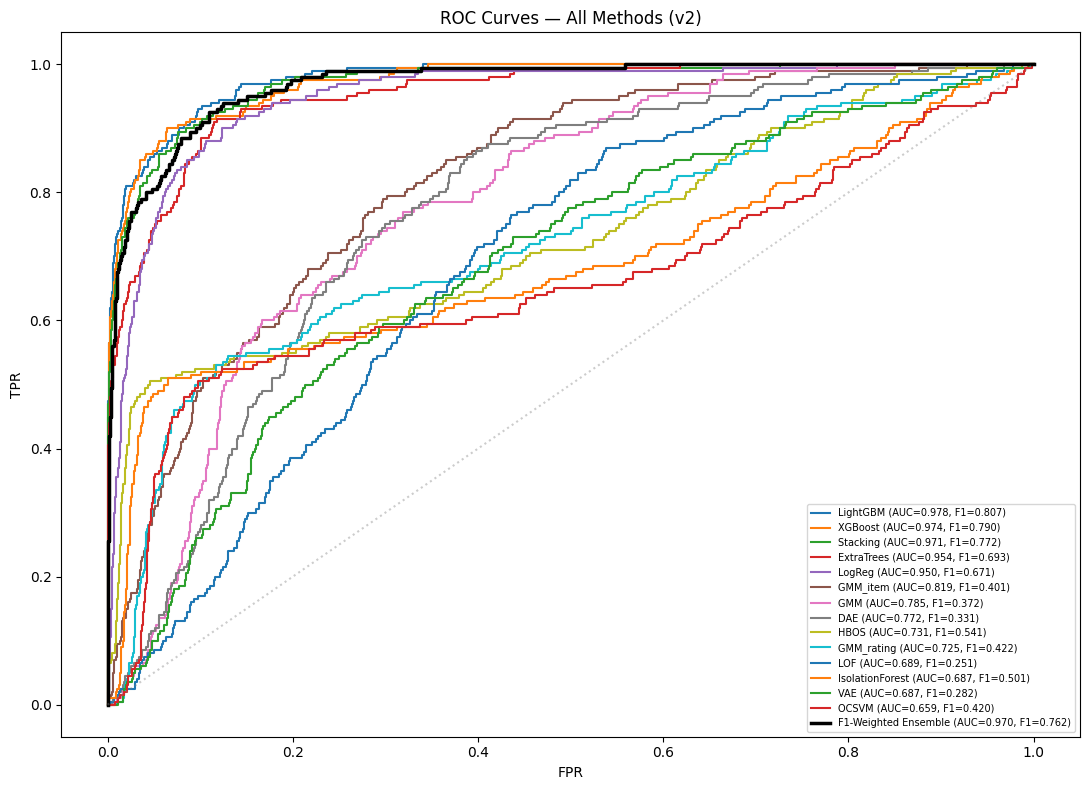

In [27]:
# ROC curves
plt.figure(figsize=(11, 8))
for name, (scores, auc, f1) in sorted(method_scores.items(), key=lambda x: -x[1][1]):
    lw    = 1.5 if auc >= ENSEMBLE_AUC_THRESHOLD else 0.8
    style = '-'  if auc >= ENSEMBLE_AUC_THRESHOLD else '--'
    fpr, tpr, _ = roc_curve(y_true, scores)
    plt.plot(fpr, tpr, linestyle=style, linewidth=lw, label=f'{name} (AUC={auc:.3f}, F1={f1:.3f})')

fpr_e, tpr_e, _ = roc_curve(y_true, FINAL_ENSEMBLE_OOF)
plt.plot(fpr_e, tpr_e, 'k-', linewidth=2.5,
         label=f'{FINAL_LABEL} (AUC={FINAL_AUC:.3f}, F1={FINAL_F1:.3f})')
plt.plot([0,1],[0,1],'grey', linestyle=':', alpha=0.4)
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC Curves — All Methods (v2)')
plt.legend(fontsize=7, loc='lower right')
plt.tight_layout()
plt.show()

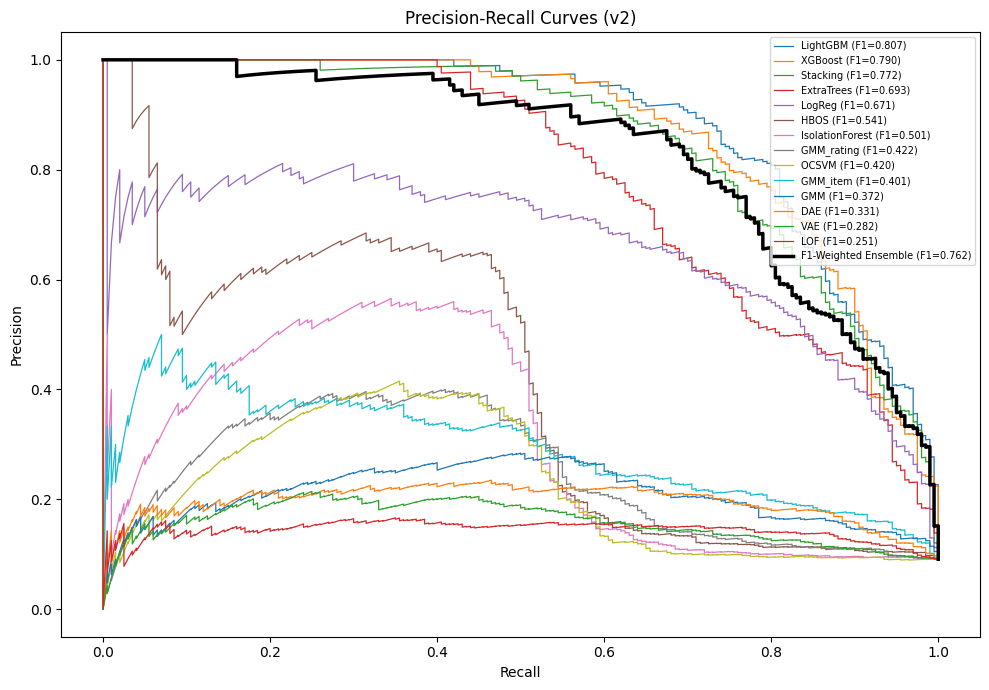

In [28]:
# Precision-Recall curves
plt.figure(figsize=(10, 7))
for name, (scores, auc, f1) in sorted(method_scores.items(), key=lambda x: -x[1][2]):
    precs_c, recs_c, _ = precision_recall_curve(y_true, scores)
    plt.plot(recs_c, precs_c, linewidth=0.9, label=f'{name} (F1={f1:.3f})')

precs_e, recs_e, _ = precision_recall_curve(y_true, FINAL_ENSEMBLE_OOF)
plt.plot(recs_e, precs_e, 'k-', linewidth=2.5,
         label=f'{FINAL_LABEL} (F1={FINAL_F1:.3f})')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curves (v2)')
plt.legend(fontsize=7, loc='upper right')
plt.tight_layout()
plt.show()

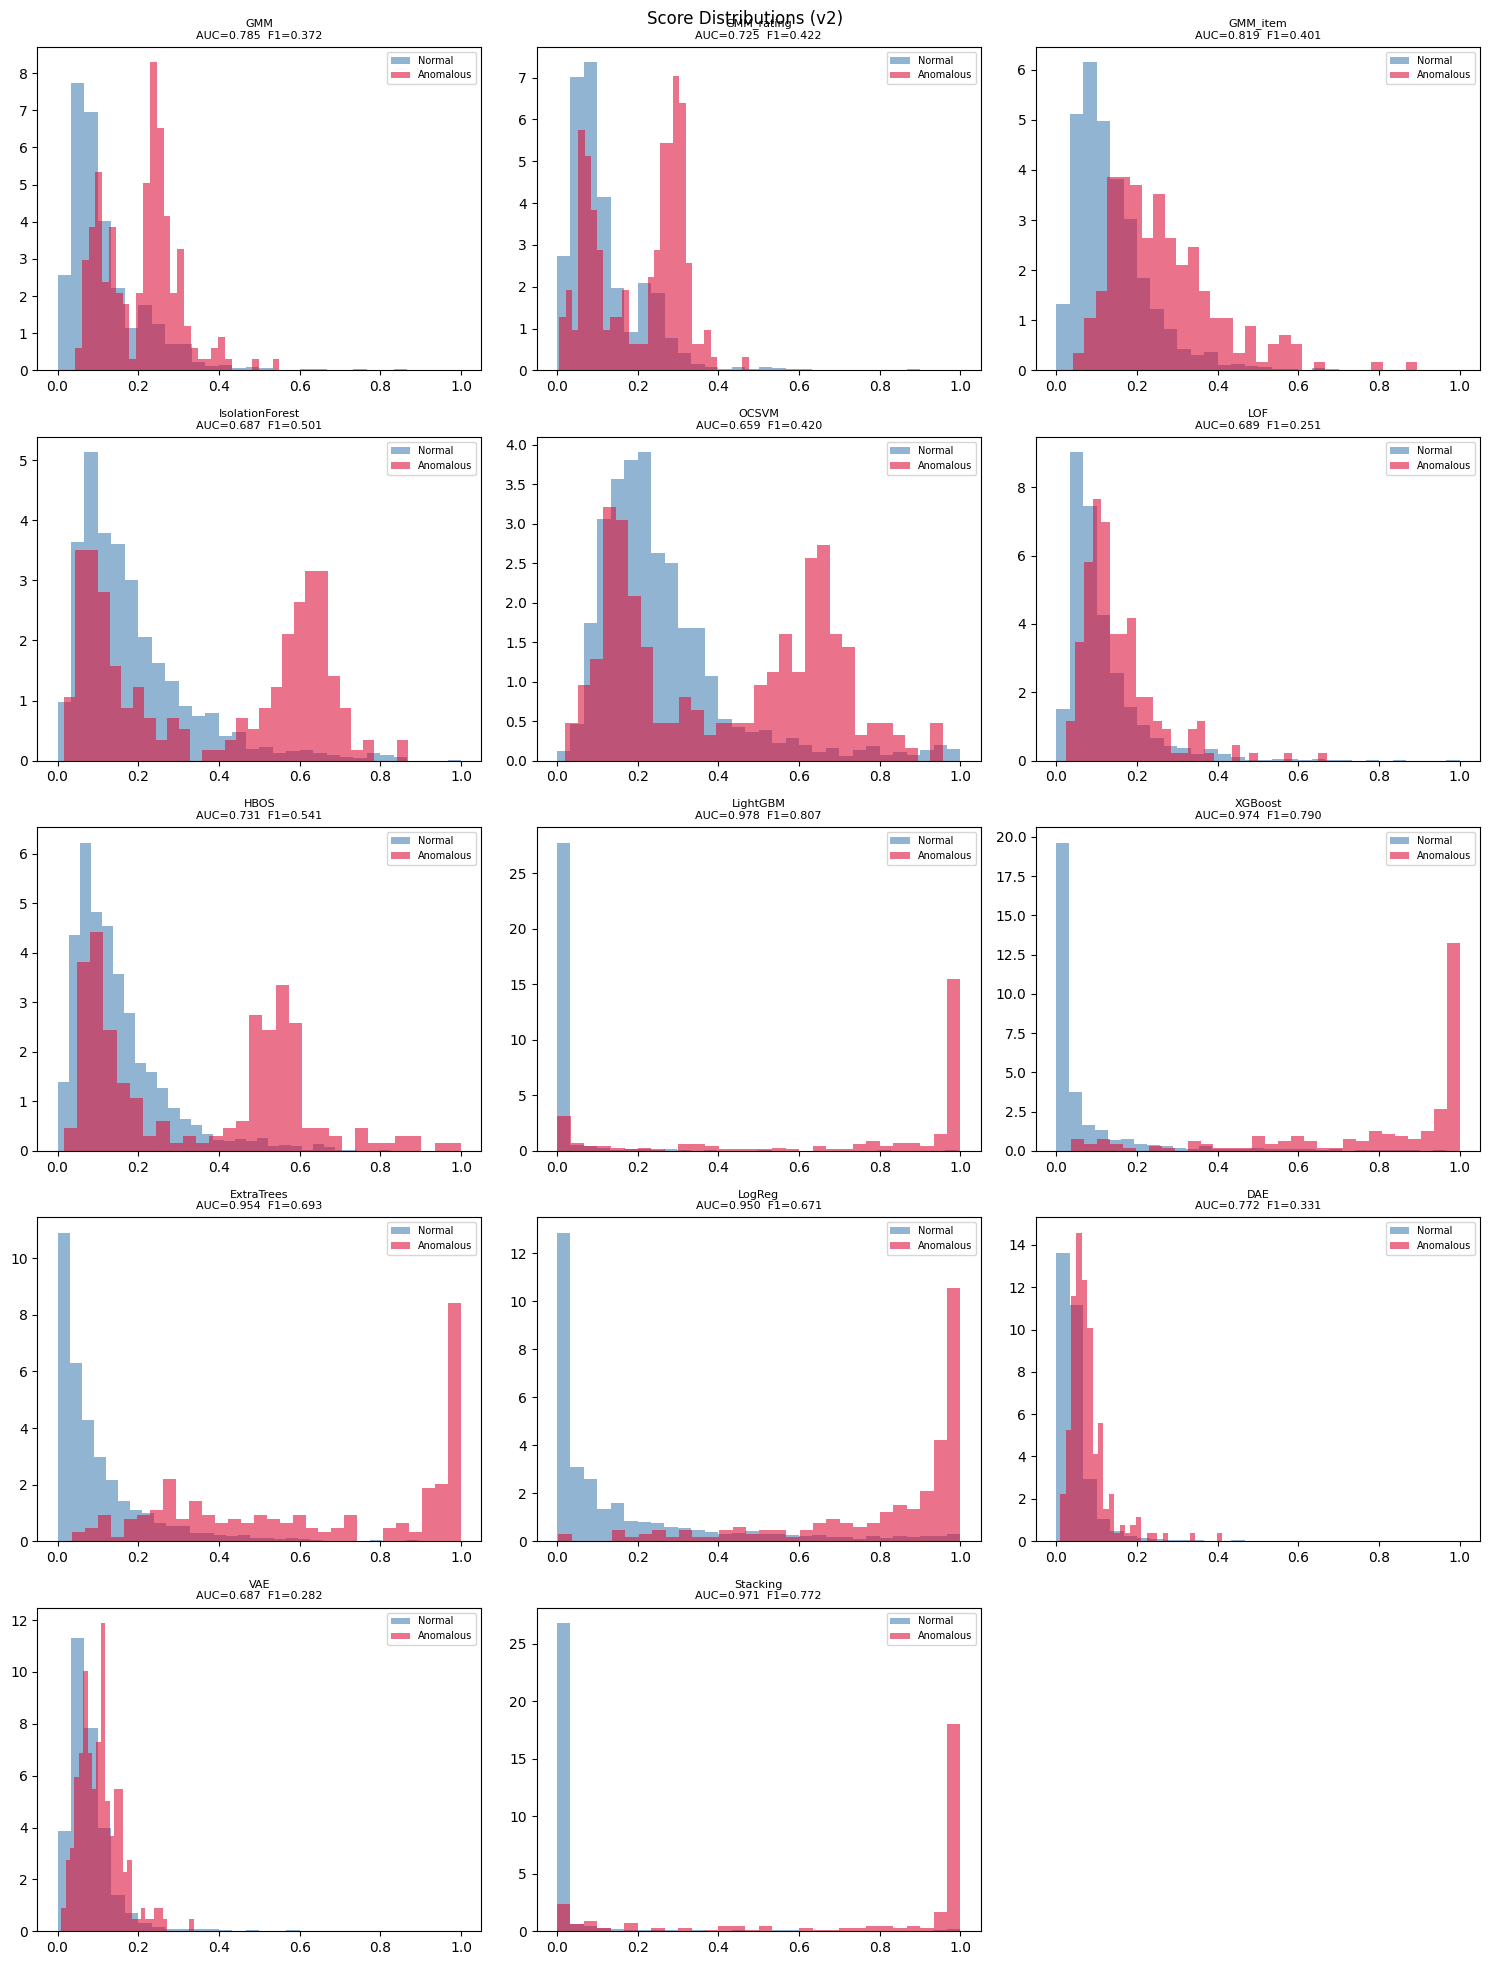

In [29]:
# Score distributions
n_methods = len(method_scores)
ncols = 3; nrows = (n_methods + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4*nrows))
axes = axes.flatten()
for i, (name, (scores, auc, f1)) in enumerate(method_scores.items()):
    ax = axes[i]
    ax.hist(scores[y_true==0], bins=30, alpha=0.6, label='Normal',    color='steelblue', density=True)
    ax.hist(scores[y_true==1], bins=30, alpha=0.6, label='Anomalous', color='crimson',   density=True)
    ax.set_title(f'{name}\nAUC={auc:.3f}  F1={f1:.3f}', fontsize=8)
    ax.legend(fontsize=7)
for j in range(n_methods, len(axes)): axes[j].set_visible(False)
plt.suptitle('Score Distributions (v2)', fontsize=12)
plt.tight_layout()
plt.show()

In [30]:
# Results table
results_df = pd.DataFrame(results)
cols_show  = ['model', 'AUC', 'F1', 'Precision', 'Recall', 'threshold', 'flags']
cols_show  = [c for c in cols_show if c in results_df.columns]
results_df = results_df[cols_show].sort_values('F1', ascending=False).reset_index(drop=True)
print('=== Model Comparison (sorted by F1) ===')
print(results_df.to_string(index=False, float_format='%.4f'))

=== Model Comparison (sorted by F1) ===
                          model    AUC     F1  Precision  Recall  threshold  flags
           LightGBM (5-fold CV) 0.9782 0.8070     0.8090  0.8050     0.3064    199
           LightGBM (5-fold CV) 0.9782 0.8070     0.8090  0.8050     0.3064    199
            XGBoost (5-fold CV) 0.9736 0.7902     0.8683  0.7250     0.7095    167
          Stacking meta-learner 0.9710 0.7725     0.8202  0.7300     0.7507    178
           F1-Weighted Ensemble 0.9699 0.7616     0.8424  0.6950     0.4248    165
         ExtraTrees (5-fold CV) 0.9542 0.6931     0.7360  0.6550     0.4473    178
Logistic Regression (5-fold CV) 0.9500 0.6715     0.6495  0.6950     0.8081    214
                   HBOS bins=30 0.7311 0.5407     0.6458  0.4650    84.0313    144
      IsolationForest cont=0.01 0.6872 0.5013     0.5439  0.4650    -0.0831    171
                 GMM rating n=5 0.7247 0.4220     0.3898  0.4600    45.3609    236
                   OCSVM nu=0.2 0.6595 0.4196  

**Step 14: Test Scoring & Submission**

In [31]:
TEST_FILE = '../second_batch.npz'   # ← update each week

data_test = np.load(TEST_FILE)
df_test   = pd.DataFrame(data_test['X'], columns=['user', 'item', 'rating'])

# ── Compute test SVD features (project onto training item factors) ────────────
# For test users, rebuild SVD on combined train+test for a shared latent space,
# then extract test-user rows. This avoids cold-start issues.
df_combined = pd.concat([XX, df_test], ignore_index=True)
SVD_LATENT_FULL, SVD_RECON_FULL, SVD_USER_IDS_FULL = compute_svd_features(df_combined, n_components=SVD_K)

# ── Engineer test features using training item stats ──────────────────────────
test_feat_all, test_user_ids, _ = engineer_all_features(
    df_test, n_items=1000,
    normal_centroid=NORMAL_CENTROID,
    item_mean=ITEM_MEAN, item_count=ITEM_COUNT, item_pop_rank=ITEM_POP_RANK,
    svd_latent=SVD_LATENT_FULL, svd_recon=SVD_RECON_FULL,
    svd_user_ids=SVD_USER_IDS_FULL,
    svd_normal_centroid=SVD_NORMAL_CENTROID
)

# Sort by user_id (required by Codabench)
sort_order    = np.argsort(test_user_ids)
test_user_ids = test_user_ids[sort_order]
test_feat_all = test_feat_all[sort_order]

# Scale
test_feat      = test_feat_all[:, selected_idx]
test_rating    = test_feat_all[:, rating_idx]
test_item_f    = test_feat_all[:, item_idx]

test_scaled    = scaler.transform(test_feat)
test_rating_s  = rating_scaler.transform(test_rating)
test_item_s    = item_scaler.transform(test_item_f)
X_test_t       = torch.FloatTensor(test_scaled).to(DEVICE)

print(f'Test users        : {len(test_user_ids)}')
print(f'User ID range     : [{test_user_ids.min()}, {test_user_ids.max()}]')
print(f'Test interactions : {len(df_test):,}')

Test users        : 860
User ID range     : [4100, 4959]
Test interactions : 134,594


In [32]:
def vae_score_fn(model, X_t):
    model.eval()
    scores = []
    with torch.no_grad():
        for i in range(len(X_t)):
            x = X_t[i].unsqueeze(0)
            recon, mu, logvar = model(x)
            rec = nn.functional.mse_loss(recon, x, reduction='sum').item()
            kl  = (-0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())).item()
            scores.append(rec + 0.5 * kl)
    return np.array(scores)


# ── Score each component on test data ─────────────────────────────────────────
test_score_dict = {}

# Unsupervised
test_score_dict['GMM']          = normalize(-gmm.score_samples(test_scaled))
test_score_dict['GMM_rating']   = normalize(-gmm_rating.score_samples(test_rating_s))
test_score_dict['GMM_item']     = normalize(-gmm_item.score_samples(test_item_s))
test_score_dict['IsolationForest'] = normalize(-iforest.decision_function(test_scaled))
test_score_dict['OCSVM']        = normalize(-ocsvm.decision_function(test_scaled))
test_score_dict['LOF']          = normalize(-lof.decision_function(test_scaled))
test_score_dict['HBOS']         = normalize(hbos_score(X_train_normal, test_scaled,
                                                         n_bins=best_hbos_bins))
test_score_dict['DAE']          = normalize(dae_model.reconstruction_error(X_test_t))
test_score_dict['VAE']          = normalize(vae_score_fn(vae_model, X_test_t))

# Supervised (average over fold models for stability)
test_score_dict['LightGBM']     = normalize(np.mean([m.predict_proba(test_scaled)[:,1]
                                                       for m in lgbm_fold_models], axis=0))
test_score_dict['XGBoost']      = normalize(np.mean([m.predict_proba(test_scaled)[:,1]
                                                       for m in xgb_fold_models], axis=0))
test_score_dict['LogReg']       = normalize(lr_full.predict_proba(test_scaled)[:, 1])
test_score_dict['ExtraTrees']   = normalize(np.mean([m.predict_proba(test_scaled)[:,1]
                                                       for m in et_models], axis=0))

# Stacking meta prediction
t_sup   = np.column_stack([test_score_dict[n] for n in sup_stack_names])
t_unsup = np.column_stack([test_score_dict[n] for n in unsup_names])
t_stack = np.hstack([t_sup, t_unsup])
test_score_dict['Stacking'] = normalize(np.mean([m.predict_proba(t_stack)[:,1]
                                                    for m in meta_models], axis=0))

print('All test scores computed.')
for name, sc in test_score_dict.items():
    print(f'  {name:<25} range=[{sc.min():.3f}, {sc.max():.3f}]')

All test scores computed.
  GMM                       range=[0.000, 1.000]
  GMM_rating                range=[0.000, 1.000]
  GMM_item                  range=[0.000, 1.000]
  IsolationForest           range=[0.000, 1.000]
  OCSVM                     range=[0.000, 1.000]
  LOF                       range=[0.000, 1.000]
  HBOS                      range=[0.000, 1.000]
  DAE                       range=[0.000, 1.000]
  VAE                       range=[0.000, 1.000]
  LightGBM                  range=[0.000, 1.000]
  XGBoost                   range=[0.000, 1.000]
  LogReg                    range=[0.000, 1.000]
  ExtraTrees                range=[0.000, 1.000]
  Stacking                  range=[0.000, 1.000]


In [33]:
# ── Build test ensemble score ──────────────────────────────────────────────────
test_ensemble_raw = np.zeros(len(test_user_ids))
for name in FINAL_WEIGHTS:
    if name in test_score_dict:
        test_ensemble_raw += FINAL_WEIGHTS[name] * test_score_dict[name]
    else:
        print(f'  Warning: {name} not in test_score_dict — skipping')

test_ensemble_raw = normalize(test_ensemble_raw)

# ── Calibrate: shift so F1-optimal threshold → 0.5 ───────────────────────────
# Use OOF ensemble scores as the reference distribution for calibration.
sub_final = calibrate_scores(FINAL_ENSEMBLE_OOF, y_true, test_ensemble_raw)

print(f'\n=== Submission Score Summary ===')
print(f'Raw ensemble range        : [{test_ensemble_raw.min():.4f}, {test_ensemble_raw.max():.4f}]')
print(f'Calibrated range          : [{sub_final.min():.4f}, {sub_final.max():.4f}]')
print(f'OOF F1-optimal threshold  : {FINAL_THR:.4f} → mapped to 0.5 after calibration')
print(f'Users predicted anomalous : {(sub_final >= 0.5).sum()} / {len(sub_final)}')

# ── Save submission ───────────────────────────────────────────────────────────
np.savez('../submission.npz', predictions=sub_final)

print(f'\nSaved submission.npz')
print(f'  {len(sub_final)} predictions')
print(f'  User ID range: [{test_user_ids.min()}, {test_user_ids.max()}]')
print(f'  → zip submission.npz → submission.zip → upload to Codabench')


=== Submission Score Summary ===
Raw ensemble range        : [0.0000, 1.0000]
Calibrated range          : [0.1307, 1.0000]
OOF F1-optimal threshold  : 0.4248 → mapped to 0.5 after calibration
Users predicted anomalous : 54 / 860

Saved submission.npz
  860 predictions
  User ID range: [4100, 4959]
  → zip submission.npz → submission.zip → upload to Codabench


In [34]:
# ── Training-data score analysis (using OOF calibrated scores) ───────────────
# This shows what F1 / precision / recall you would get at various thresholds
# on the training data. Use this to verify the calibration is correct.

oof_cal = calibrate_scores(FINAL_ENSEMBLE_OOF, y_true, FINAL_ENSEMBLE_OOF)

print('=== OOF calibrated score analysis (training data) ===')
print(f'{"Threshold":>10}  {"Precision":>10}  {"Recall":>8}  {"F1":>8}  {"Flags":>6}')
for thr in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:
    n_flags = int((oof_cal >= thr).sum())
    tp      = int(((oof_cal >= thr) & (y_true == 1)).sum())
    prec_v  = tp / max(n_flags, 1)
    rec_v   = tp / max(y_true.sum(), 1)
    f1_v    = 2 * prec_v * rec_v / (prec_v + rec_v + 1e-9)
    marker  = '  ← optimal' if abs(thr - 0.50) < 0.01 else ''
    print(f'  {thr:>8.2f}  {prec_v:>10.4f}  {rec_v:>8.4f}  {f1_v:>8.4f}  {n_flags:>6}{marker}')

print(f'\nTraining AUC of calibrated scores: {roc_auc_score(y_true, oof_cal):.4f}')
_, best_cal_f1 = find_f1_optimal_threshold(oof_cal, y_true)
print(f'Best reachable F1 on training OOF: {best_cal_f1:.4f}')

=== OOF calibrated score analysis (training data) ===
 Threshold   Precision    Recall        F1   Flags
      0.30      0.4479    0.9250    0.6036     413
      0.35      0.5484    0.8500    0.6667     310
      0.40      0.6299    0.8000    0.7048     254
      0.45      0.7602    0.7450    0.7525     196
      0.50      0.8424    0.6950    0.7616     165  ← optimal
      0.55      0.8921    0.6200    0.7316     139
      0.60      0.9189    0.5100    0.6559     111
      0.65      0.9375    0.4500    0.6081      96
      0.70      0.9740    0.3750    0.5415      77

Training AUC of calibrated scores: 0.9699
Best reachable F1 on training OOF: 0.7616
